In [3]:
import torch
from Bio.PDB import PDBParser, DSSP, PPBuilder
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import numpy as np
import pandas as pd
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
tasks = pd.read_csv('/home/alon.kitin/fs-dock/data/fsdock/test_tasks.csv')
tasks = tasks[tasks['assay_id']=='CHEMBL1119333'].reset_index(drop=True)
tasks

,Unnamed: 0,assay_id,target_id,protein_path,ligand_path,label,type
0,328,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,0,B
1,329,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,0,B
2,330,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,0,B
3,331,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,0,B
4,332,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,0,B
...,...,...,...,...,...,...,...
412,740,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,1,B
413,741,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,1,B
414,742,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,1,B
415,743,CHEMBL1119333,P22303,/home/alon.kitin/docking_cfom/data/proteins/pd...,/home/alon.kitin/docking_cfom/data/CHEMBL11193...,1,B


In [5]:
def visualize_protein_ligand(pdb_file, sdf_files):
    colors = ['red', 'blue', 'green', 'yellow', 'orange', 'purple']
    # Load the protein
    with open(pdb_file, 'r') as file:
        pdb_data = file.read()

    # Load the ligand
    # Create the viewer
    viewer = py3Dmol.view(width=800, height=600)
    viewer.addModel(pdb_data, 'pdb')
    # viewer.setStyle({'cartoon': {'color': 'spectrum'}})
    viewer.addSurface(py3Dmol.VDW, {'opacity': 0.9, 'color': 'white'})
    # Show carbon atoms of the protein as green dots
    viewer.setStyle({'model': 0}, {'sphere': {'color': 'green', 'radius': 0.2}})
    for i,(c, sdf_file) in enumerate(zip(colors, sdf_files)):
        ligand = Chem.SDMolSupplier(sdf_file)[0]
        ligand_block = Chem.MolToMolBlock(ligand)
        viewer.addModel(ligand_block, 'mol')
        viewer.setStyle({'model': i+1}, {'stick': {'color': c}})
    viewer.zoomTo()
    return viewer.show()


In [7]:
i=0
visualize_protein_ligand(tasks['protein_path'][i], tasks['ligand_path'][1:4])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

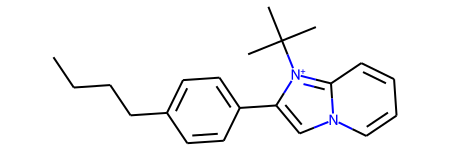

In [ ]:
Chem.MolFromSmiles('CCCCc1ccc(-c2cn3ccccc3[n+]2C(C)(C)C)cc1')

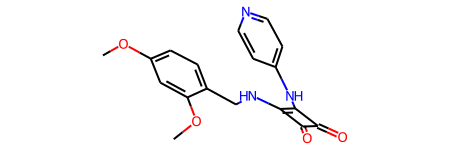

COc1ccc(CNc2c(Nc3ccncc3)c(=O)c2=O)c(OC)c1


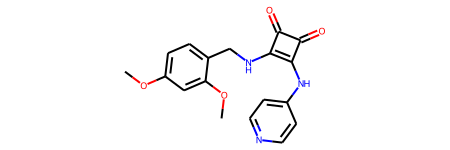

In [ ]:
ligand = Chem.SDMolSupplier(tasks['ligand_path'][0])[0]
print(Chem.MolToSmiles(ligand))
Chem.MolFromSmiles(Chem.MolToSmiles(ligand))


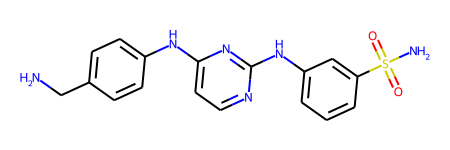

In [ ]:
Chem.MolFromSmiles('NCc1ccc(Nc2ccnc(Nc3cccc(S(N)(=O)=O)c3)n2)cc1')


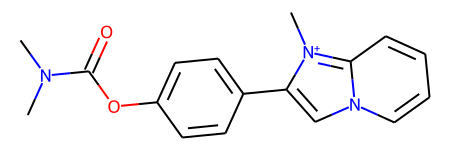

In [ ]:
Chem.MolFromSmiles('CN(C)C(=O)Oc1ccc(-c2cn3ccccc3[n+]2C)cc1')
